# Optimization + ML hybrid: full walkthrough

This notebook holds **all** implementation code. Run cells **top to bottom** from the repository root with your virtual environment as the Jupyter kernel.

**Data:** by default, **real** weekly demand from [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) (`config/experiment.yaml`: `data_source: uci_online_retail`). Set `data_source: synthetic` for the Poisson simulator. **Story:** multi-SKU demand → two forecasts (seasonal naive vs gradient boosting on lags) → linear inventory program with a service constraint → realized costs under **true** demand.

**In-notebook analysis:** section 8 prints styled tables, cost gaps vs oracle, stress results, and short interpretation (after you run the pipeline in section 7).

**Optional exports:** from the repo root run `python scripts/generate_report.py` to refresh `report.html` and `outputs/`. Long-form write-up: **`REPORT.md`**.

**Why not end-to-end RL?** Reinforcement learning fits when a trusted simulator and stable actions exist. Here we keep **auditable** linear constraints and explicit costs. RL is a natural extension later.

**Solvers:** PuLP with the bundled CBC LP engine (no paid licenses).


## 1. Environment

Create a venv, run `pip install -r requirements.txt` (includes **openpyxl** for the real retail Excel file), and select that interpreter as your Jupyter kernel. Uncomment `%pip` below only if something is missing.


In [1]:
# Uncomment if needed:
# %pip install pandas numpy scikit-learn pyyaml pulp matplotlib seaborn jinja2 openpyxl

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal

import json
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import pulp as pl


## 2. Config helpers

Experiment knobs and unit costs live in `config/experiment.yaml` and `config/costs.yaml`. The helper below loads them.


In [2]:
def load_yaml(path: Path | str) -> dict[str, Any]:
    p = Path(path)
    with p.open("r", encoding="utf-8") as f:
        return yaml.safe_load(f)


## 3. Demand data (real or synthetic)

**Config** (`config/experiment.yaml`) sets `data_source`:

- **`uci_online_retail`** (default): [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) — real transactions. We download the spreadsheet once into `data/raw/`, aggregate **units sold per StockCode per calendar week**, keep the top SKUs by volume, and encode weeks as integer periods `0 … T-1`.

- **`synthetic`**: the documented simulator below (Poisson demand, seasonality). Use this for a fully controlled lab or if you are offline.

Train vs test is always a **time cutoff** on periods (`train_period_fraction` in config).


In [3]:
import urllib.request


def load_uci_online_retail_long(
    root: Path,
    url: str,
    top_n_skus: int,
    min_distinct_weeks: int,
) -> pd.DataFrame:
    """Weekly demand panel from UCI Online Retail (real data). Columns: sku, period, demand."""
    raw = root / "data" / "raw"
    raw.mkdir(parents=True, exist_ok=True)
    dest = raw / "Online_Retail.xlsx"
    if not dest.is_file():
        urllib.request.urlretrieve(url, dest)
    retail = pd.read_excel(dest, engine="openpyxl")
    retail = retail.dropna(subset=["StockCode", "InvoiceDate"])
    retail = retail[retail["Quantity"] > 0].copy()
    retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], errors="coerce")
    retail = retail.dropna(subset=["InvoiceDate"])
    retail["week"] = retail["InvoiceDate"].dt.to_period("W-SUN").dt.start_time
    agg = retail.groupby(["StockCode", "week"], as_index=False)["Quantity"].sum()
    vol = agg.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False)
    top_codes = vol.head(top_n_skus).index.tolist()
    agg = agg[agg["StockCode"].isin(top_codes)].copy()
    weeks_sorted = sorted(agg['week'].unique())
    if len(weeks_sorted) < min_distinct_weeks:
        raise ValueError(
            f"After filtering, only {len(weeks_sorted)} distinct weeks "
            f"(need >= {min_distinct_weeks}). Lower uci_min_distinct_weeks or uci_top_n_skus."
        )
    week_to_idx = {w: i for i, w in enumerate(weeks_sorted)}
    code_to_sku = {c: i for i, c in enumerate(top_codes)}
    agg["sku"] = agg["StockCode"].map(code_to_sku)
    agg["period"] = agg["week"].map(week_to_idx)
    agg["demand"] = agg["Quantity"].clip(lower=0).astype(int)
    out = agg.groupby(["sku", "period"], as_index=False)["demand"].sum()
    return out[["sku", "period", "demand"]]


def generate_synthetic_demand(
    n_skus: int,
    n_periods: int,
    random_state: np.random.Generator | None = None,
) -> pd.DataFrame:
    rng = random_state or np.random.default_rng(42)
    rows: list[dict] = []
    for s in range(n_skus):
        level = rng.lognormal(mean=np.log(8 + s * 0.15), sigma=0.35)
        phase = rng.uniform(0, 2 * np.pi)
        for t in range(n_periods):
            season = 1.0 + 0.22 * np.sin(2 * np.pi * t / 52.0 + phase)
            noise = rng.lognormal(mean=0.0, sigma=0.12)
            mu = max(0.5, level * season * noise)
            d = rng.poisson(lam=float(mu))
            rows.append({"sku": s, "period": t, "demand": int(d)})
    return pd.DataFrame(rows)


def add_train_test_split(df: pd.DataFrame, train_period_fraction: float) -> pd.DataFrame:
    t_max = int(df["period"].max())
    cutoff = int(np.floor(train_period_fraction * (t_max + 1)))
    out = df.copy()
    out["split"] = np.where(out["period"] < cutoff, "train", "test")
    return out


## 4. Forecasting layer

- **Naive:** same week last year (or closest lag) per SKU.
- **ML:** `HistGradientBoostingRegressor` on lags (1, 2, 7, 14) and SKU id; recursive one-step forecasts on the test window.

Both return a **wide** matrix: periods × SKUs, for the test horizon.


In [4]:
def pivot_from_long(long_df: pd.DataFrame) -> pd.DataFrame:
    return (
        long_df.pivot_table(index="period", columns="sku", values="demand", aggfunc="sum")
        .sort_index()
        .fillna(0.0)
    )


def _lags(s: pd.Series, periods: list[int]) -> pd.DataFrame:
    out = {}
    for p in periods:
        out[f"lag_{p}"] = s.shift(p)
    return pd.DataFrame(out)


@dataclass
class ForecastResult:
    name: str
    y_hat_wide: pd.DataFrame


def fit_naive_seasonal(
    train_wide: pd.DataFrame,
    test_index: pd.Index,
    season_length: int = 52,
) -> pd.DataFrame:
    preds = []
    for col in train_wide.columns:
        s = train_wide[col].astype(float)
        yhat = []
        for t in test_index:
            lag_idx = t - season_length
            if lag_idx in s.index:
                yhat.append(float(s.loc[lag_idx]))
            else:
                yhat.append(float(s.iloc[-min(len(s), season_length)]))
        preds.append(pd.Series(yhat, index=test_index, name=col))
    return pd.concat(preds, axis=1)


def build_supervised_from_long(
    long_df: pd.DataFrame,
    train_periods: set[int],
) -> tuple[pd.DataFrame, pd.Series]:
    parts = []
    for sku, g in long_df.groupby("sku"):
        g = g.sort_values("period")
        s = g.set_index("period")["demand"].astype(float)
        feat = _lags(s, [1, 2, 7, 14])
        feat["sku"] = float(sku)
        feat["period"] = g["period"].values
        feat["y"] = s.values
        parts.append(feat)
    Xy = pd.concat(parts, ignore_index=True)
    Xy = Xy.dropna()
    mask = Xy["period"].isin(train_periods)
    feature_cols = [c for c in Xy.columns if c not in ("y", "period")]
    X = Xy.loc[mask, feature_cols]
    y = Xy.loc[mask, "y"]
    return X, y


def predict_ml_test_periods(
    long_full: pd.DataFrame,
    train_periods: set[int],
    test_periods: list[int],
    random_state: int = 42,
) -> pd.DataFrame:
    from sklearn.ensemble import HistGradientBoostingRegressor

    test_periods = sorted(test_periods)
    sku_list = sorted(long_full["sku"].unique())
    wide_truth = pivot_from_long(long_full)
    sim = wide_truth.astype(float).copy()

    X_tr, y_tr = build_supervised_from_long(long_full, train_periods)
    model = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.08,
        max_iter=200,
        random_state=random_state,
    )
    model.fit(X_tr, y_tr)

    preds: dict[int, dict[int, float]] = {}
    for t in test_periods:
        preds[t] = {}
        for sku in sku_list:
            row = {
                "lag_1": float(sim.loc[t - 1, sku]) if t - 1 in sim.index else 0.0,
                "lag_2": float(sim.loc[t - 2, sku]) if t - 2 in sim.index else 0.0,
                "lag_7": float(sim.loc[t - 7, sku]) if t - 7 in sim.index else 0.0,
                "lag_14": float(sim.loc[t - 14, sku]) if t - 14 in sim.index else 0.0,
                "sku": float(sku),
            }
            X_row = pd.DataFrame([row])
            yhat = float(model.predict(X_row)[0])
            preds[t][sku] = max(0.0, yhat)
        for sku in sku_list:
            sim.loc[t, sku] = preds[t][sku]

    out = pd.DataFrame(preds).T.sort_index()
    out.index.name = "period"
    out.columns = [int(c) for c in out.columns]
    return out


def run_forecast_suite(
    long_df: pd.DataFrame,
    train_period_fraction: float,
    kind: Literal["naive", "ml", "both"] = "both",
    random_state: int = 42,
) -> dict[str, ForecastResult]:
    t_max = int(long_df["period"].max())
    cutoff = int(np.floor(train_period_fraction * (t_max + 1)))
    train_periods = set(range(0, cutoff))
    test_periods = list(range(cutoff, t_max + 1))
    wide = pivot_from_long(long_df)
    train_wide = wide.loc[wide.index < cutoff]
    test_idx = wide.loc[wide.index >= cutoff].index
    results: dict[str, ForecastResult] = {}

    if kind in ("naive", "both"):
        naive = fit_naive_seasonal(train_wide, test_idx)
        results["naive"] = ForecastResult("naive_seasonal", naive)

    if kind in ("ml", "both"):
        ml_wide = predict_ml_test_periods(long_df, train_periods, test_periods, random_state)
        results["ml"] = ForecastResult("hgb_lag", ml_wide)

    return results


## 5. Inventory LP (decision layer)

Multi-SKU, multi-period linear program: orders, end inventory, shortages; holding + variable ordering + shortage penalties; aggregate fill-rate constraint on **planning** demand; per-period order capacity. Fixed ordering costs are **not** in the LP (would need binaries); they are charged when simulating realized KPIs below.


In [5]:
@dataclass
class InventoryPlan:
    orders: pd.DataFrame
    inventory_end: pd.DataFrame
    shortage: pd.DataFrame
    objective_value: float
    status: str
    solver_name: str


def solve_inventory_lp(
    demand: pd.DataFrame,
    costs: dict[str, float],
    initial_inventory: float | dict[Any, float],
    min_fill_rate: float,
) -> InventoryPlan:
    demand = demand.astype(float).copy()
    periods = list(demand.index)
    skus = list(demand.columns)

    if isinstance(initial_inventory, dict):
        I0 = {s: float(initial_inventory[s]) for s in skus}
    else:
        I0 = {s: float(initial_inventory) for s in skus}

    h = float(costs["holding_per_unit_period"])
    c_var = float(costs["ordering_variable_per_unit"])
    c_short = float(costs["stockout_penalty_per_unit"])
    cap = float(costs["order_capacity_per_period"])

    prob = pl.LpProblem("inventory_lp", pl.LpMinimize)

    x: dict[tuple[Any, Any], pl.LpVariable] = {}
    Iend: dict[tuple[Any, Any], pl.LpVariable] = {}
    sht: dict[tuple[Any, Any], pl.LpVariable] = {}

    for t in periods:
        for s in skus:
            x[t, s] = pl.LpVariable(f"x_{t}_{s}", lowBound=0)
            Iend[t, s] = pl.LpVariable(f"I_{t}_{s}", lowBound=0)
            sht[t, s] = pl.LpVariable(f"u_{t}_{s}", lowBound=0)

    prob += pl.lpSum(
        h * Iend[t, s] + c_var * x[t, s] + c_short * sht[t, s] for t in periods for s in skus
    )

    for ti, t in enumerate(periods):
        prob += pl.lpSum(x[t, s] for s in skus) <= cap
        for s in skus:
            d = float(demand.loc[t, s])
            prob += sht[t, s] <= d
            if ti == 0:
                prev_i = I0[s]
            else:
                prev_i = Iend[periods[ti - 1], s]
            prob += Iend[t, s] == prev_i + x[t, s] - d + sht[t, s]

    total_demand = float(demand.to_numpy().sum())
    max_short = (1.0 - min_fill_rate) * total_demand
    prob += pl.lpSum(sht[t, s] for t in periods for s in skus) <= max_short

    solver = pl.PULP_CBC_CMD(msg=False, timeLimit=300)
    prob.solve(solver)
    status = pl.LpStatus[prob.status]

    orders = pd.DataFrame(
        [[pl.value(x[t, s]) or 0.0 for s in skus] for t in periods],
        index=periods,
        columns=skus,
    )
    inv = pd.DataFrame(
        [[pl.value(Iend[t, s]) or 0.0 for s in skus] for t in periods],
        index=periods,
        columns=skus,
    )
    sh = pd.DataFrame(
        [[pl.value(sht[t, s]) or 0.0 for s in skus] for t in periods],
        index=periods,
        columns=skus,
    )
    obj_val = float(pl.value(prob.objective) or 0.0)

    return InventoryPlan(
        orders=orders,
        inventory_end=inv,
        shortage=sh,
        objective_value=obj_val,
        status=status,
        solver_name="CBC_LP",
    )


solve_inventory_milp = solve_inventory_lp


## 6. Evaluation (simulation under true demand)

We build order plans using **forecast** demand in the LP, then roll the system forward with **true** demand to compute realized cost and fill rate. The oracle benchmark solves the LP on **true** demand for the test horizon.


In [6]:
@dataclass
class KPIReport:
    name: str
    total_cost: float
    fill_rate: float
    total_shortage: float
    total_demand: float


def simulate_orders_against_truth(
    orders: pd.DataFrame,
    demand_true: pd.DataFrame,
    initial_inventory: float | dict[int, float],
    costs: dict[str, float],
) -> KPIReport:
    demand_true = demand_true.astype(float).reindex_like(orders).fillna(0.0)
    periods = list(orders.index)
    skus = list(orders.columns)
    if isinstance(initial_inventory, dict):
        I0 = {s: float(initial_inventory[s]) for s in skus}
    else:
        I0 = {s: float(initial_inventory) for s in skus}

    h = float(costs["holding_per_unit_period"])
    c_var = float(costs["ordering_variable_per_unit"])
    c_fix = float(costs["ordering_fixed_per_order"])
    c_short = float(costs["stockout_penalty_per_unit"])

    I_prev = {s: I0[s] for s in skus}
    total_cost = 0.0
    total_short = 0.0
    total_d = 0.0

    for t in periods:
        for s in skus:
            x = max(0.0, float(orders.loc[t, s]))
            d = float(demand_true.loc[t, s])
            avail = I_prev[s] + x
            fulfilled = min(avail, d)
            sht = d - fulfilled
            I_prev[s] = avail - fulfilled
            total_short += sht
            total_d += d
            total_cost += h * I_prev[s]
            total_cost += c_var * x
            if x > 1e-8:
                total_cost += c_fix
            total_cost += c_short * sht

    fill = (total_d - total_short) / total_d if total_d > 0 else 1.0
    return KPIReport(
        name="simulated",
        total_cost=total_cost,
        fill_rate=float(fill),
        total_shortage=total_short,
        total_demand=total_d,
    )


def oracle_plan_and_kpis(
    demand_true: pd.DataFrame,
    costs: dict[str, float],
    initial_inventory: float,
    min_fill_rate: float,
) -> tuple[InventoryPlan, KPIReport]:
    plan = solve_inventory_milp(
        demand_true,
        costs,
        initial_inventory=initial_inventory,
        min_fill_rate=min_fill_rate,
    )
    kpi = simulate_orders_against_truth(
        plan.orders,
        demand_true,
        initial_inventory=initial_inventory,
        costs=costs,
    )
    kpi.name = "oracle_milp_truth"
    return plan, kpi


def scenario_kpi(
    label: str,
    demand_forecast: pd.DataFrame,
    demand_true: pd.DataFrame,
    costs: dict[str, float],
    initial_inventory: float,
    min_fill_rate: float,
) -> tuple[InventoryPlan, KPIReport]:
    plan = solve_inventory_milp(
        demand_forecast,
        costs,
        initial_inventory=initial_inventory,
        min_fill_rate=min_fill_rate,
    )
    kpi = simulate_orders_against_truth(
        plan.orders,
        demand_true,
        initial_inventory=initial_inventory,
        costs=costs,
    )
    kpi.name = label
    return plan, kpi


def stress_demand(demand: pd.DataFrame, factor: float) -> pd.DataFrame:
    return (demand.astype(float) * factor).clip(lower=0.0)


## 7. End-to-end run

Load config, simulate demand, fit forecasts on the test horizon, compare **oracle** vs **naive + LP** vs **ML + LP**, save CSVs and a bar chart under `outputs/`, and run a small demand stress sweep on the naive-based plan.


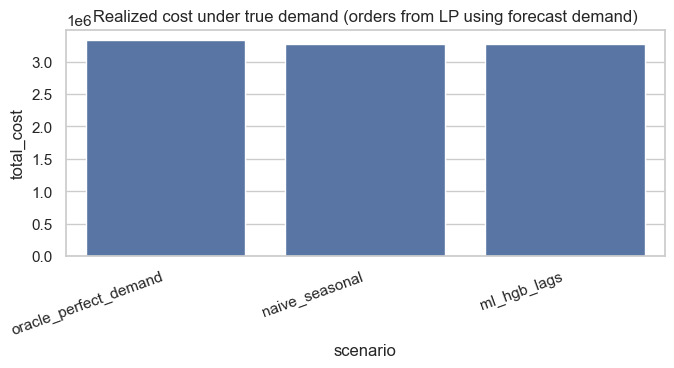

Saved CSVs, figure, and manifest under C:\Users\Jesco\Documents\GitHub\optimization-ml-hybrid\outputs


In [7]:
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "config" / "costs.yaml").is_file():
            return p
        p = p.parent
    raise FileNotFoundError("Need config/costs.yaml — run Jupyter from the repository root.")

ROOT = find_repo_root()

if "load_yaml" not in globals():
    def load_yaml(path):
        p = Path(path)
        with p.open("r", encoding="utf-8") as f:
            return yaml.safe_load(f)

sns.set_theme(style="whitegrid")
OUT = ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

exp = load_yaml(ROOT / "config" / "experiment.yaml")
costs = load_yaml(ROOT / "config" / "costs.yaml")
rng = np.random.default_rng(int(exp["random_seed"]))

ds = str(exp.get("data_source", "synthetic")).lower()
if ds == "uci_online_retail":
    long_df = load_uci_online_retail_long(
        ROOT,
        url=str(exp["uci_online_retail_url"]),
        top_n_skus=int(exp["uci_top_n_skus"]),
        min_distinct_weeks=int(exp.get("uci_min_distinct_weeks", 40)),
    )
elif ds == "synthetic":
    long_df = generate_synthetic_demand(
        int(exp["n_skus"]), int(exp["n_periods"]), random_state=rng
    )
else:
    raise ValueError(f"Unknown data_source: {ds!r}; use 'synthetic' or 'uci_online_retail'.")

long_df = add_train_test_split(long_df, float(exp["train_period_fraction"]))

wide = pivot_from_long(long_df)
cutoff = int(np.floor(float(exp["train_period_fraction"]) * (int(long_df["period"].max()) + 1)))
test_wide = wide.loc[wide.index >= cutoff]

fc = run_forecast_suite(long_df, float(exp["train_period_fraction"]), kind="both", random_state=int(exp["random_seed"]))
naive_hat = fc["naive"].y_hat_wide.reindex_like(test_wide).fillna(0.0)
ml_hat = fc["ml"].y_hat_wide.reindex_like(test_wide).fillna(0.0)

min_fr = float(exp["min_fill_rate"])
I0 = float(costs["initial_inventory"])

rows = []
oracle_plan, oracle_kpi = oracle_plan_and_kpis(test_wide, costs, I0, min_fr)
rows.append({"scenario": "oracle_perfect_demand", "total_cost": oracle_kpi.total_cost, "fill_rate": oracle_kpi.fill_rate})

for label, dhat in [("naive_seasonal", naive_hat), ("ml_hgb_lags", ml_hat)]:
    _, kpi = scenario_kpi(label, dhat, test_wide, costs, I0, min_fr)
    rows.append({"scenario": label, "total_cost": kpi.total_cost, "fill_rate": kpi.fill_rate})

summary = pd.DataFrame(rows)
summary.to_csv(OUT / "kpi_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=summary, x="scenario", y="total_cost", ax=ax)
ax.set_title("Realized cost under true demand (orders from LP using forecast demand)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(OUT / "cost_by_scenario.png", dpi=150)
plt.show()
plt.close(fig)

stress_rows = []
for m in exp["stress_multipliers"]:
    d_stress = stress_demand(test_wide, float(m))
    _, k = scenario_kpi(f"naive_x{m}", naive_hat, d_stress, costs, I0, min_fr)
    stress_rows.append({"multiplier": m, "total_cost": k.total_cost, "fill_rate": k.fill_rate})
stress_summary = pd.DataFrame(stress_rows)
stress_summary.to_csv(OUT / "sensitivity_naive_forecast.csv", index=False)

with open(OUT / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "n_skus": int(long_df["sku"].nunique()),
            "n_periods": int(long_df["period"].nunique()),
            "cutoff": cutoff,
            "data_source": str(exp.get("data_source", "synthetic")),
        },
        f,
        indent=2,
    )

print("Saved CSVs, figure, and manifest under", OUT.resolve())


## 8. Results and analysis

After running section 7, use this section for **tables and interpretation** in the notebook. The same numbers are saved under `outputs/` for reports.


In [8]:
from IPython.display import display, Markdown

display(Markdown("**Realized total cost and fill rate** (orders from the LP built on forecast or oracle demand; simulation uses **true** test demand)."))
display(summary.style.format({"total_cost": "{:,.2f}", "fill_rate": "{:.4f}"}).hide(axis="index"))

oracle_cost = float(summary.loc[summary["scenario"].str.contains("oracle", case=False), "total_cost"].iloc[0])
lines = ["**Cost gap vs oracle (percent)**", ""]
for _, r in summary.iterrows():
    if "oracle" in r["scenario"].lower():
        continue
    gap = (float(r["total_cost"]) - oracle_cost) / oracle_cost * 100
    lines.append(f"- {r['scenario']}: **{gap:+.1f}%** (realized cost {float(r['total_cost']):,.2f}, fill {float(r['fill_rate']):.4f})")
display(Markdown(chr(10).join(lines)))

display(Markdown("**Stress test:** same naive-based order rule; **true** demand scaled by the multiplier."))
display(stress_summary.style.format({"multiplier": "{:.1f}", "total_cost": "{:,.2f}", "fill_rate": "{:.4f}"}).hide(axis="index"))

display(Markdown("""**How to read this**

- **Oracle** is a perfect-foresight benchmark on the **test window** (true demand inside the LP).
- **Naive / ML** put forecast demand into the LP; realized cost and fill use **truth**, so ranking can disagree with forecast accuracy (predict-then-optimize gap).
- **Stress** moves true demand without refitting forecasts: you see cost and service sensitivity to scale misspecification.

Tweak `config/experiment.yaml` or the RNG seed and re-run sections 7 and 8 to explore."""))


**Realized total cost and fill rate** (orders from the LP built on forecast or oracle demand; simulation uses **true** test demand).

scenario,total_cost,fill_rate
oracle_perfect_demand,"3,328,858.25",0.0270
naive_seasonal,"3,271,715.00",0.0422
ml_hgb_lags,"3,274,647.89",0.0400


**Cost gap vs oracle (percent)**

- naive_seasonal: **-1.7%** (realized cost 3,271,715.00, fill 0.0422)
- ml_hgb_lags: **-1.6%** (realized cost 3,274,647.89, fill 0.0400)

**Stress test:** same naive-based order rule; **true** demand scaled by the multiplier.

multiplier,total_cost,fill_rate
0.9,"2,945,405.70",0.0434
1.0,"3,271,715.00",0.0422
1.1,"3,599,179.22",0.0410


**How to read this**

- **Oracle** is a perfect-foresight benchmark on the **test window** (true demand inside the LP).
- **Naive / ML** put forecast demand into the LP; realized cost and fill use **truth**, so ranking can disagree with forecast accuracy (predict-then-optimize gap).
- **Stress** moves true demand without refitting forecasts: you see cost and service sensitivity to scale misspecification.

Tweak `config/experiment.yaml` or the RNG seed and re-run sections 7 and 8 to explore.